In [3]:
source = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data"
caption_target  = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/unimodal_text_filter"
vision_target  = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/unimodal_vision_filter"
alignment_target = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/multimodal_alignment_filter"

specificity_source = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/multimodal_specificity_filter/20250620_163413_00000000.txt"
specificity_target = "/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/multimodal_specificity_filter/full_datacomp_multimodal_specificity_filter_output.txt"

In [4]:
from made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from made.data_pipeline.utils import connect_or_start_ray, collect_tar_files, cleanup, remove_and_recreate_dirs


/home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-15 12:13:41,965	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [5]:
def get_dataset(data_dir, get_images=False, get_captions=True):
    dataset = iter(decode_webdataset(
        collect_tar_files(data_dir, recursive=True),
        get_images=get_images,
        get_captions=get_captions,
        batch_size=1000
    ))
    return dataset

In [6]:
def get_captions_lens(dataset):
    caption_lens = []
    while True:
        try:
            batch = next(dataset)
        except StopIteration:
            break
        uids = batch[0]
        captions = batch[1]
        caption_lens.extend([len(caption) for caption in captions])
    return caption_lens

In [7]:
def get_aspect_ratios(dataset):
    aspect_ratios = []
    while True:
        try:
            batch = next(dataset)
        except StopIteration:
            break
        uids = batch[0]
        images = batch[1]
        captions = batch[2]
        aspect_ratios.extend([image.width / image.height for image in images])
    return aspect_ratios

In [8]:
def clip_score(processor, model, image, caption):
    try:
        inputs = processor(text=[caption], images=[image], return_tensors="pt", padding=True, truncation=True, max_length=77).to("cuda")
        with torch.no_grad():
            outputs = model(**inputs)
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds
            similarity = F.cosine_similarity(image_embeds, text_embeds)
            return similarity.item()
    except Exception as e:
        print(e)
        return None
from transformers import CLIPProcessor, CLIPModel
import torch
import torch.nn.functional as F

def get_clip_scores(dataset):
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval().to("cuda")

    clip_scores = []
    while True:
        try:
            batch = next(dataset)
        except StopIteration:
            break
        uids = batch[0]
        images = batch[1]
        captions = batch[2]
        clip_scores.extend([clip_score(processor, model, image, caption) for image, caption in zip(images, captions) if clip_score(processor, model, image, caption) is not None])
    return clip_scores

In [14]:
source_caption_lens = get_captions_lens(get_dataset(source))
target_caption_lens = get_captions_lens(get_dataset(caption_target))

2025-07-15 12:16:50,468	INFO utils.py:50 -- Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data


2025-07-15 12:16:53,277	INFO utils.py:50 -- Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/unimodal_text_filter


In [9]:
source_aspect_ratios = get_aspect_ratios(get_dataset(source, get_images=True))
target_aspect_ratios = get_aspect_ratios(get_dataset(vision_target, get_images=True))

2025-07-15 12:13:56,654	INFO utils.py:50 -- Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data


2025-07-15 12:14:14,331	INFO utils.py:50 -- Found 24 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/post_made_distributions_plot/distribution_plots/output/unimodal_vision_filter


In [ ]:
source_alignment = get_clip_scores(get_dataset(source, get_images=True))
target_alignment = get_clip_scores(get_dataset(alignment_target, get_images=True))

2025-07-15 12:17:55,894	INFO utils.py:50 -- Found 4 tar files from /home/leobaro/workspace/labs/fair_spoke_8/data_quality_pipeline/benchmark/data
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The channel dimension is ambiguous. Got image shape (3, 5, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape (3, 5, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transf

mean must have 1 elements if it is an iterable, got 3


The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


mean must have 1 elements if it is an iterable, got 3


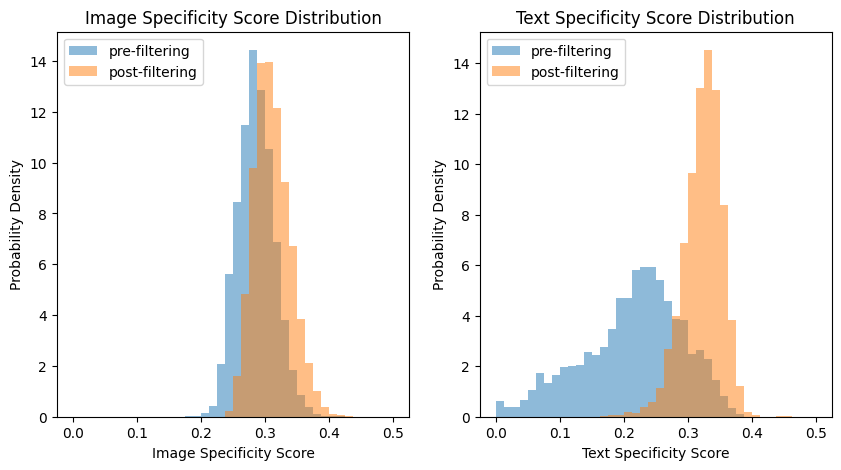

In [51]:
with open(specificity_source, "r") as f:
    lines = f.readlines()
lines = [line.strip().split(" ") for line in lines]
lines = [[float(line[0]), float(line[1])] for line in lines]
source_image_specificity_scores = [line[0] for line in lines]
source_text_specificity_scores = [line[1] for line in lines]

with open(specificity_target, "r") as f:
    lines = f.readlines()
lines = [line.strip().split(" ") for line in lines]
lines = [[float(line[0]), float(line[1])] for line in lines]
target_image_specificity_scores = [line[0] for line in lines]
target_text_specificity_scores = [line[1] for line in lines]

fig, axes = plt.subplots(1,2, figsize=(10, 5))
axes[0].hist(source_image_specificity_scores, bins=40, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
axes[0].hist(target_image_specificity_scores, bins=40, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)
axes[1].hist(source_text_specificity_scores, bins=40, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
axes[1].hist(target_text_specificity_scores, bins=40, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)
axes[0].set_xlabel("Image Specificity Score")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("Image Specificity Score Distribution")
axes[1].set_xlabel("Text Specificity Score")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Text Specificity Score Distribution")
axes[0].legend()
axes[1].legend()
fig.savefig("image_specificity_score_distribution.png", dpi=300)

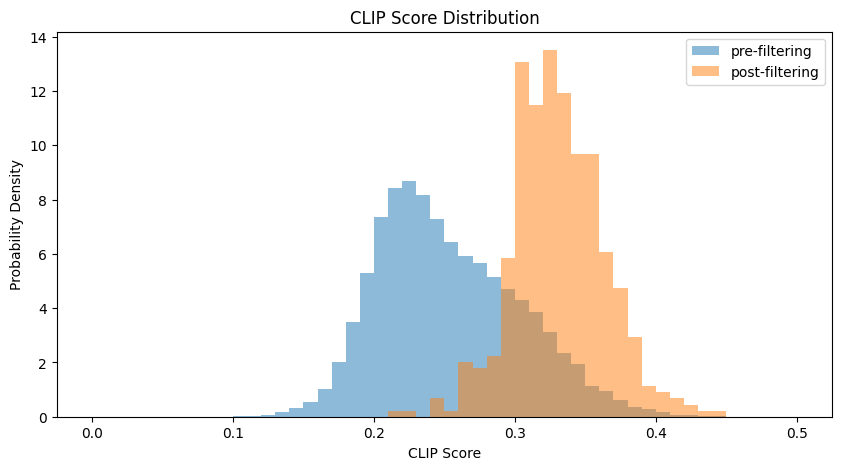

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(source_alignment, bins=50, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
ax.hist(target_alignment, bins=50, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)

ax.set_xlabel("CLIP Score")
ax.set_ylabel("Probability Density")
ax.set_title("CLIP Score Distribution")
ax.legend()
fig.savefig("clip_score_distribution.png", dpi=300)
plt.show()

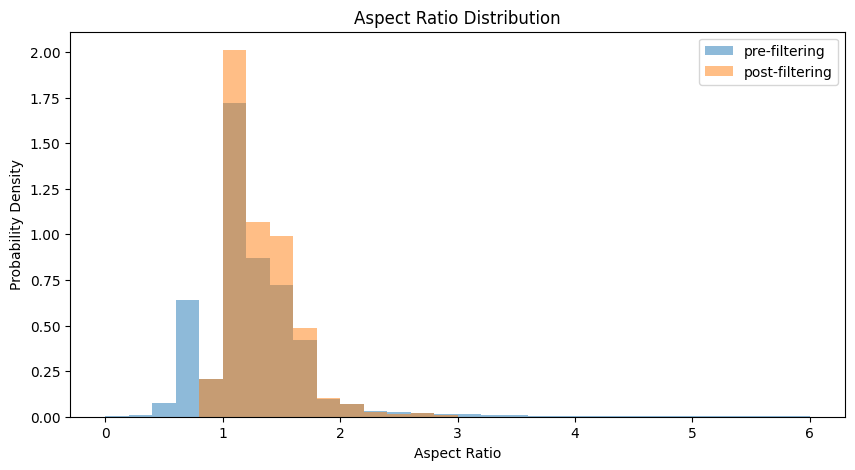

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(source_aspect_ratios, bins=30, range=(0, 6), label="pre-filtering", alpha=0.5, density=True)
ax.hist(target_aspect_ratios, bins=30, range=(0, 6), label="post-filtering", alpha=0.5, density=True)

ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Probability Density")
ax.set_title("Aspect Ratio Distribution")
ax.legend()
fig.savefig("aspect_ratio_distribution.png", dpi=300)
plt.show()

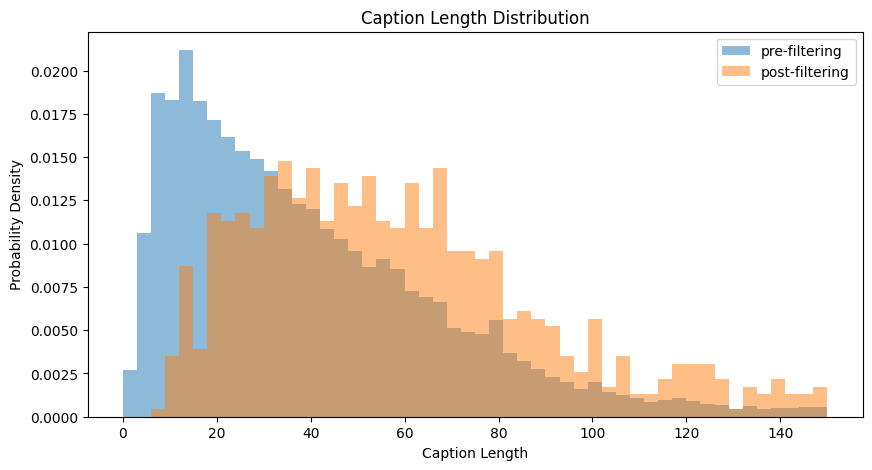

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(source_caption_lens, bins=50, range=(0, 150), label="pre-filtering", alpha=0.5, density=True)
ax.hist(target_caption_lens, bins=50, range=(0, 150), label="post-filtering", alpha=0.5, density=True)
ax.set_xlabel("Caption Length")
ax.set_ylabel("Probability Density")
ax.set_title("Caption Length Distribution")
ax.legend()
fig.savefig("caption_length_distribution.png", dpi=300)
plt.show()

NameError: name 'source_alignment' is not defined

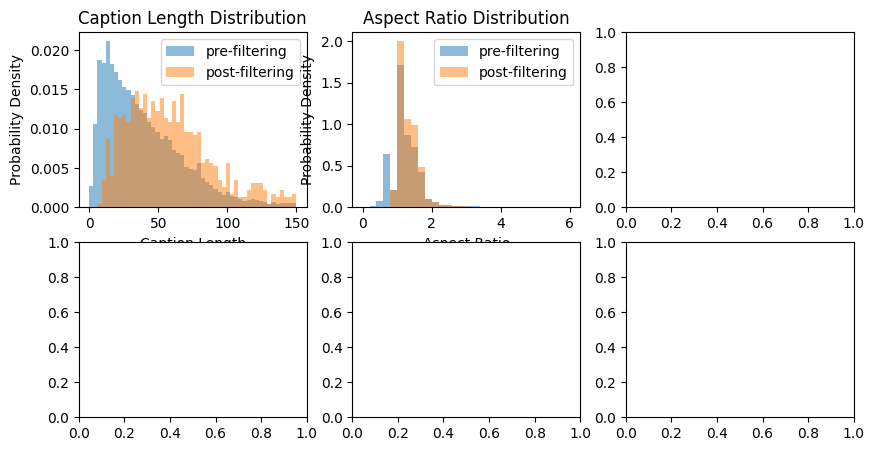

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

axes[0][0].hist(source_caption_lens, bins=50, range=(0, 150), label="pre-filtering", alpha=0.5, density=True)
axes[0][0].hist(target_caption_lens, bins=50, range=(0, 150), label="post-filtering", alpha=0.5, density=True)
axes[0][0].set_xlabel("Caption Length")
axes[0][0].set_ylabel("Probability Density")
axes[0][0].set_title("Caption Length Distribution")
axes[0][0].legend()

axes[0][1].hist(source_aspect_ratios, bins=30, range=(0, 6), label="pre-filtering", alpha=0.5, density=True)
axes[0][1].hist(target_aspect_ratios, bins=30, range=(0, 6), label="post-filtering", alpha=0.5, density=True)
axes[0][1].set_xlabel("Aspect Ratio")
axes[0][1].set_ylabel("Probability Density")
axes[0][1].set_title("Aspect Ratio Distribution")
axes[0][1].legend()

axes[0][2].hist(source_alignment, bins=50, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
axes[0][2].hist(target_alignment, bins=50, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)
axes[0][2].set_xlabel("CLIP Score")
axes[0][2].set_ylabel("Probability Density")
axes[0][2].set_title("CLIP Score Distribution")
ax.legend()


axes[1][0].hist(source_image_specificity_scores, bins=40, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
axes[1][0].hist(target_image_specificity_scores, bins=40, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)
axes[1][0].set_xlabel("Image Specificity Score")
axes[1][0].set_ylabel("Probability Density")
axes[1][0].set_title("Image Specificity Score Distribution")
axes[1][0].legend()


axes[1][1].hist(source_text_specificity_scores, bins=40, range=(0, 0.5), label="pre-filtering", alpha=0.5, density=True)
axes[1][1].hist(target_text_specificity_scores, bins=40, range=(0, 0.5), label="post-filtering", alpha=0.5, density=True)
axes[1][1].set_xlabel("Text Specificity Score")
axes[1][1].set_ylabel("Probability Density")
axes[1][1].set_title("Text Specificity Score Distribution")
axes[1][1].legend()

fig.tight_layout()
fig.savefig("distributions.png", dpi=300)

plt.show()
